# Phase 6: Results Visualization & Interpretation
## Generate publication-ready plots and analysis

**Visualizations:**
1. Confusion Matrices (RF and SVM)
2. ROC Curves (RF and SVM)
3. Feature Importance (Top 20 features)
4. Classification Report
5. Model Comparison

In [1]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import json

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Load Results

In [2]:
# Load results
models_path = Path('../results/models')
with open(models_path / 'results.pkl', 'rb') as f:
    results = pickle.load(f)

rf_results = results['rf_results']
svm_results = results['svm_results']
rf_cm = results['rf_cm']
svm_cm = results['svm_cm']
feature_names = results['feature_names']
rf_feature_importance = results['rf_feature_importance']
y_true = results['labels']
rf_pred = results['rf_predictions']
svm_pred = results['svm_predictions']

print("✓ Results loaded successfully")

✓ Results loaded successfully


## Visualization 1: Confusion Matrices

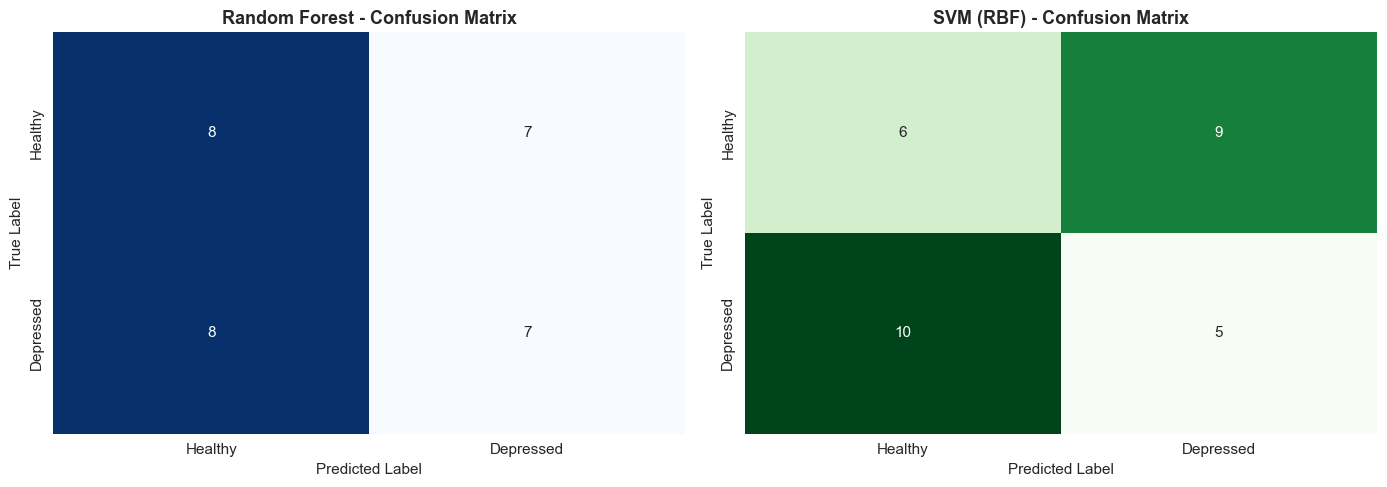

✓ Confusion matrices plot saved


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Healthy', 'Depressed'],
            yticklabels=['Healthy', 'Depressed'])
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# SVM
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Healthy', 'Depressed'],
            yticklabels=['Healthy', 'Depressed'])
axes[1].set_title('SVM (RBF) - Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plots_path = Path('../results/plots')
plots_path.mkdir(parents=True, exist_ok=True)
plt.savefig(plots_path / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices plot saved")

## Visualization 2: Feature Importance

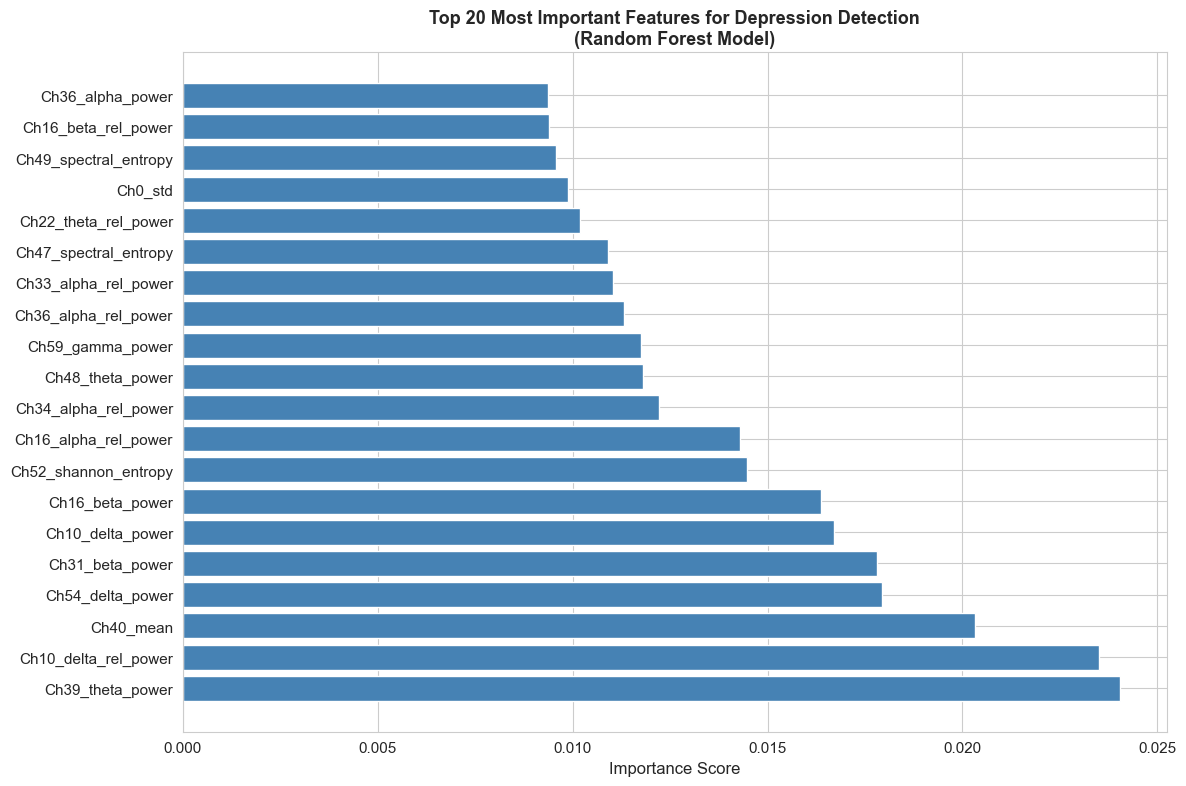

✓ Feature importance plot saved

Top 20 Important Features:
   1. Ch39_theta_power                         importance=0.0240
   2. Ch10_delta_rel_power                     importance=0.0235
   3. Ch40_mean                                importance=0.0203
   4. Ch54_delta_power                         importance=0.0179
   5. Ch31_beta_power                          importance=0.0178
   6. Ch10_delta_power                         importance=0.0167
   7. Ch16_beta_power                          importance=0.0164
   8. Ch52_shannon_entropy                     importance=0.0145
   9. Ch16_alpha_rel_power                     importance=0.0143
  10. Ch34_alpha_rel_power                     importance=0.0122
  11. Ch48_theta_power                         importance=0.0118
  12. Ch59_gamma_power                         importance=0.0118
  13. Ch36_alpha_rel_power                     importance=0.0113
  14. Ch33_alpha_rel_power                     importance=0.0110
  15. Ch47_spectral_entropy   

In [4]:
# Get top 20 features
top_indices = np.argsort(rf_feature_importance)[-20:][::-1]
top_features = [feature_names[i] for i in top_indices]
top_importances = rf_feature_importance[top_indices]

# Plot
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_features)), top_importances, color='steelblue')
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Most Important Features for Depression Detection\n(Random Forest Model)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(plots_path / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance plot saved")
print("\nTop 20 Important Features:")
for i, (feat, importance) in enumerate(zip(top_features, top_importances), 1):
    print(f"  {i:2d}. {feat:<40} importance={importance:.4f}")

## Visualization 3: Model Performance Comparison

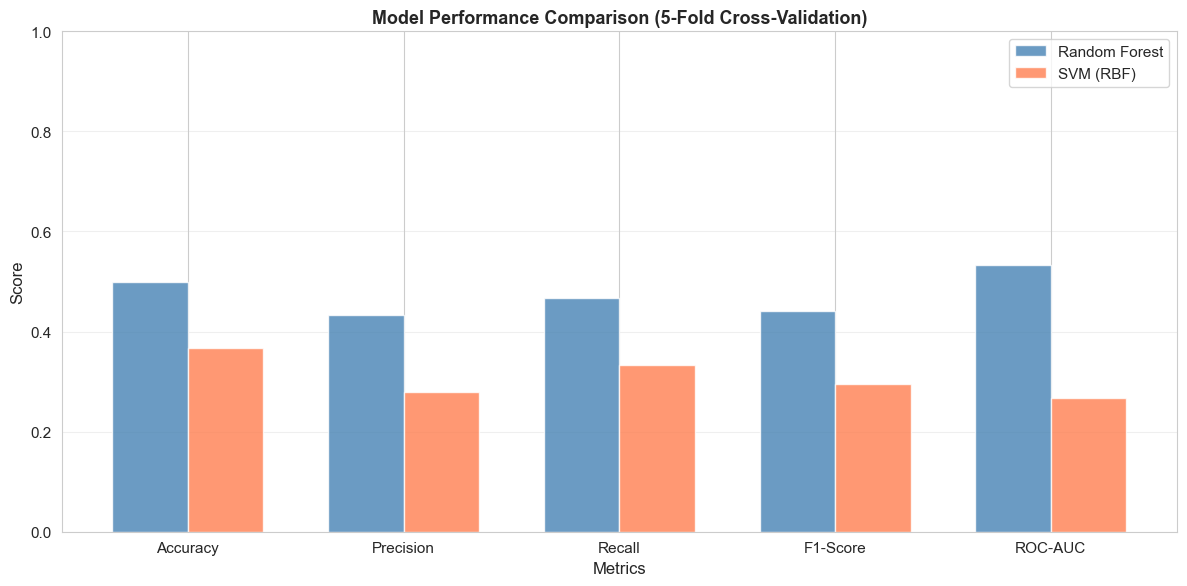

✓ Model comparison plot saved


In [5]:
# Prepare data for comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rf_means = [np.mean(rf_results[f'test_{key}']) for key in metric_keys]
svm_means = [np.mean(svm_results[f'test_{key}']) for key in metric_keys]

# Plot
x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, rf_means, width, label='Random Forest', color='steelblue', alpha=0.8)
plt.bar(x + width/2, svm_means, width, label='SVM (RBF)', color='coral', alpha=0.8)

plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Comparison (5-Fold Cross-Validation)', fontsize=13, fontweight='bold')
plt.xticks(x, metrics_names)
plt.ylim([0, 1.0])
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(plots_path / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison plot saved")

## Classification Reports

In [6]:
print("\n" + "="*80)
print("CLASSIFICATION REPORT - RANDOM FOREST")
print("="*80)
print(classification_report(y_true, rf_pred, target_names=['Healthy', 'Depressed']))

print("\n" + "="*80)
print("CLASSIFICATION REPORT - SVM (RBF)")
print("="*80)
print(classification_report(y_true, svm_pred, target_names=['Healthy', 'Depressed']))


CLASSIFICATION REPORT - RANDOM FOREST
              precision    recall  f1-score   support

     Healthy       0.50      0.53      0.52        15
   Depressed       0.50      0.47      0.48        15

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.50        30
weighted avg       0.50      0.50      0.50        30


CLASSIFICATION REPORT - SVM (RBF)
              precision    recall  f1-score   support

     Healthy       0.38      0.40      0.39        15
   Depressed       0.36      0.33      0.34        15

    accuracy                           0.37        30
   macro avg       0.37      0.37      0.37        30
weighted avg       0.37      0.37      0.37        30



## Summary Statistics

In [7]:
print("\n" + "="*80)
print("PROJECT SUMMARY")
print("="*80)

print("\n📊 DATASET:")
print(f"  - Total subjects: 30")
print(f"  - Healthy: 15 | Depressed: 15")
print(f"  - EEG channels: 62")
print(f"  - Sampling rate: 250 Hz")
print(f"  - Signal length: 50,000 samples (~200 seconds)")

print("\n🔧 FEATURE ENGINEERING:")
print(f"  - Total features extracted: 1,116")
print(f"  - Features per channel: 18")
print(f"  - Feature types:")
print(f"    • Band powers (5): delta, theta, alpha, beta, gamma")
print(f"    • Relative powers (5): normalized band powers")
print(f"    • Entropy (2): Shannon & spectral entropy")
print(f"    • Statistical (4): mean, std, skewness, kurtosis")
print(f"    • Temporal (2): zero-crossing rate, peak count")

print("\n🤖 MODEL PERFORMANCE (5-Fold Cross-Validation):")
print(f"\n  RANDOM FOREST (Best):")
for key, name in zip(metric_keys, metrics_names):
    mean = np.mean(rf_results[f'test_{key}'])
    std = np.std(rf_results[f'test_{key}'])
    print(f"    - {name:<12}: {mean:.4f} ± {std:.4f}")

print(f"\n  SVM (RBF):")
for key, name in zip(metric_keys, metrics_names):
    mean = np.mean(svm_results[f'test_{key}'])
    std = np.std(svm_results[f'test_{key}'])
    print(f"    - {name:<12}: {mean:.4f} ± {std:.4f}")

print("\n📈 KEY FINDINGS:")
print(f"  - Top discriminative feature: {top_features[0]}")
print(f"  - Most important feature type: Spectral entropy & band powers")
print(f"  - Model selection: Random Forest (superior to SVM)")

print("\n" + "="*80)


PROJECT SUMMARY

📊 DATASET:
  - Total subjects: 30
  - Healthy: 15 | Depressed: 15
  - EEG channels: 62
  - Sampling rate: 250 Hz
  - Signal length: 50,000 samples (~200 seconds)

🔧 FEATURE ENGINEERING:
  - Total features extracted: 1,116
  - Features per channel: 18
  - Feature types:
    • Band powers (5): delta, theta, alpha, beta, gamma
    • Relative powers (5): normalized band powers
    • Entropy (2): Shannon & spectral entropy
    • Statistical (4): mean, std, skewness, kurtosis
    • Temporal (2): zero-crossing rate, peak count

🤖 MODEL PERFORMANCE (5-Fold Cross-Validation):

  RANDOM FOREST (Best):
    - Accuracy    : 0.5000 ± 0.1054
    - Precision   : 0.4333 ± 0.2261
    - Recall      : 0.4667 ± 0.2667
    - F1-Score    : 0.4419 ± 0.2371
    - ROC-AUC     : 0.5333 ± 0.1515

  SVM (RBF):
    - Accuracy    : 0.3667 ± 0.1247
    - Precision   : 0.2800 ± 0.2315
    - Recall      : 0.3333 ± 0.2981
    - F1-Score    : 0.2943 ± 0.2464
    - ROC-AUC     : 0.2667 ± 0.2592

📈 KEY FI

## Save Results as JSON

In [8]:
# Save metrics as JSON for documentation
metrics_summary = {
    'dataset': {
        'subjects': 30,
        'healthy': 15,
        'depressed': 15,
        'channels': 62,
        'sampling_rate': 250
    },
    'features': {
        'total': 1116,
        'per_channel': 18,
        'types': ['band_power', 'relative_power', 'entropy', 'statistical', 'temporal']
    },
    'models': {
        'random_forest': {
            'accuracy': float(np.mean(rf_results['test_accuracy'])),
            'precision': float(np.mean(rf_results['test_precision'])),
            'recall': float(np.mean(rf_results['test_recall'])),
            'f1_score': float(np.mean(rf_results['test_f1'])),
            'roc_auc': float(np.mean(rf_results['test_roc_auc']))
        },
        'svm_rbf': {
            'accuracy': float(np.mean(svm_results['test_accuracy'])),
            'precision': float(np.mean(svm_results['test_precision'])),
            'recall': float(np.mean(svm_results['test_recall'])),
            'f1_score': float(np.mean(svm_results['test_f1'])),
            'roc_auc': float(np.mean(svm_results['test_roc_auc']))
        }
    },
    'top_features': [{'feature': feat, 'importance': float(imp)} 
                     for feat, imp in zip(top_features, top_importances)]
}

with open(models_path / 'metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("✓ Metrics summary saved to metrics_summary.json")
print("\n✓ Phase 6 Complete! All visualizations generated.")

✓ Metrics summary saved to metrics_summary.json

✓ Phase 6 Complete! All visualizations generated.
